# Data analysis project of the Marfan Power study as part of the teaching unit Movement Analysis, part 1/2
by Chloé Laignel-Granier

##  Introduction

This notebook presents the data preprocessing, analysis, and visualization pipeline for a secondary analysis of the Marfan Power dataset.

The primary objective was to evaluate changes in functional capacity following a 6-month adapted physical activity program, using the 6-minute walk test (6MWT) as the main outcome. Secondary analyses explored the relationship between functional performance and quality of life.

Data were first cleaned and standardized to ensure consistency. Patients were then selected based on the availability of complete data at baseline (T-3) and post-intervention (T+6) for the variables of interest. This selection ensured the validity of paired comparisons while maximizing the sample size.

Descriptive analyses and visualizations were performed in Python to explore the data and illustrate both individual and group-level changes. The processed dataset was subsequently exported to R for statistical analyses, including paired non-parametric tests and correlation analyse.

This pipeline provides a reproducible and transparent workflow, from raw data processing to statistical inference, in line with good scientific practices.

### Research question

Does a 6-month adapted physical activity program improve functional capacity, as assessed by the 6-minute walk test, in children with Marfan syndrome, and is this improvement associated with enhanced quality of life?

## Methods

### Study population

A total of 28 children and adolescents with Marfan syndrome were initially included in the dataset.

For this analysis, patients were selected according to predefined inclusion criteria based on data completeness at baseline (T-3) and post-intervention (T+6) for the variables of interest, including the 6-minute walk test (6MWT) and health-related quality of life (PedsQL).

A total of 20 patients met these criteria and were included in the final analysis, while 8 patients were excluded. Exclusions were primarily due to drop-out (absence of follow-up at T+6) or missing data for key variables.

This selection process ensured the validity of within-subject comparisons in the paired statistical analysis.

This approach differs from the original study design, which included multiple time points, as this analysis focused on a simplified before–after comparison.

### Data processing pipeline

The analysis followed a structured workflow to ensure consistency and reproducibility.

After initial data import, variables were standardized and checked for consistency. The dataset was then formatted to facilitate analysis, including transformation into a long format and computation of individual changes (Δ) in functional performance.

Exploratory data analysis was conducted using graphical representations to visualize distributions and individual trajectories.

The processed dataset was subsequently used for statistical analyses, including paired comparisons and correlation analyses.

This workflow ensured a clear transition from data preprocessing to statistical interpretation.

## Data preprocessing and analysis

## Step 1 : Upload the Excel data to Python

In [1]:
# Load dataset
import pandas as pd
import numpy as np
file_path = "data/Marfan.xlsx"
data = pd.read_excel(file_path)

# Display first rows and info about the dataset
print(data.head())
print(data.info())

# Total number of patients
len(data)


   ID        age sexe  weight_kg  height_cm  BMI_kg_cm2  \
0   1  10.529774    M       47.8      162.6   18.079517   
1   2  14.351814    F       43.0      174.0   14.202669   
2   3  10.704997    M       26.0      142.0   12.894267   
3   4  17.393566    F       69.0      185.5   20.052165   
4   5  18.986995    F       54.8      177.0   17.491781   

   6minWT_Distance_traveled_m_before  6minWT_Distance_traveled_m_after  \
0                                660                             737.0   
1                                598                               NaN   
2                                556                             618.0   
3                                588                             692.0   
4                                583                               NaN   

   VO2_SV1__percent_theoretical_before  VO2_SV1__percent_theoretical_after  \
0                            29.918262                           39.958707   
1                            38.742243      

28

The dataset was imported from an Excel file containing clinical and functional data of patients with Marfan syndrome.

There are 28 patients.

## Step 2 : Clean data

In [2]:
# Rename columns for clarity
data = data.rename(columns={
    "VO2_SV1__percent_theoretical_after": "VAT_after",
    "VO2_SV1__percent_theoretical_before": "VAT_before"
})

The columns have been renamed " VO2_SV1__percent_theoretical" to VAT

In [3]:
# Standardize variable names
data.columns = data.columns.str.lower().str.strip()
data.head()

,id,age,sexe,weight_kg,height_cm,bmi_kg_cm2,6minwt_distance_traveled_m_before,6minwt_distance_traveled_m_after,vat_before,vat_after,pedsql_totalself_before,pedsql_totalself_after
0,1,10.529774,M,47.8,162.6,18.079517,660,737.0,29.918262,39.958707,69.565217,75.000000
1,2,14.351814,F,43.0,174.0,14.202669,598,NaN,38.742243,NaN,86.956522,NaN
2,3,10.704997,M,26.0,142.0,12.894267,556,618.0,38.237739,41.531482,92.391304,92.391304
3,4,17.393566,F,69.0,185.5,20.052165,588,692.0,28.950695,45.052754,52.173913,57.608696
4,5,18.986995,F,54.8,177.0,17.491781,583,NaN,39.959155,NaN,76.086957,70.652174


Variable names were standardized by converting all column names to lowercase and removing leading and trailing spaces to ensure consistency and prevent errors during data processing.

In [4]:
# Data quality checks

from IPython.display import display, Markdown

display(Markdown("### Missing Data"))
missing_table = data.isna().sum().to_frame(name="Missing values")
display(missing_table)

display(Markdown("### Duplicate Observations"))
duplicates = data.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

display(Markdown("### Descriptive Statistics"))
display(data.describe().round(1))

### Missing Data

,Missing values
id,0
age,0
sexe,0
weight_kg,0
height_cm,0
bmi_kg_cm2,0
6minwt_distance_traveled_m_before,0
6minwt_distance_traveled_m_after,8
vat_before,0
vat_after,8


### Duplicate Observations

Number of duplicate rows: 0


### Descriptive Statistics

,id,age,weight_kg,height_cm,bmi_kg_cm2,6minwt_distance_traveled_m_before,6minwt_distance_traveled_m_after,vat_before,vat_after,pedsql_totalself_before,pedsql_totalself_after
count,28.0,28.0,28.0,28.0,28.0,28.0,20.0,28.0,20.0,28.0,22.0
mean,14.5,12.8,46.9,166.1,16.4,583.1,619.2,34.6,42.8,71.7,78.9
std,8.2,3.7,16.8,19.5,3.4,49.0,79.9,8.5,9.7,15.1,11.2
min,1.0,7.2,22.0,134.0,12.1,450.0,460.0,18.4,25.2,34.8,57.6
25%,7.8,10.3,31.2,149.2,13.6,559.0,582.5,29.0,38.7,64.7,72.0
50%,14.5,12.5,48.4,167.5,15.0,588.0,610.0,33.8,42.1,69.6,77.7
75%,21.2,15.5,59.4,182.2,18.9,621.2,684.5,38.9,47.8,84.0,87.8
max,28.0,19.9,82.0,199.0,24.5,660.0,744.0,56.5,63.1,93.5,97.8


Data quality was assessed by examining missing values, duplicate observations, and descriptive statistics. 

Missing data were quantified for each variable, duplicate entries were checked, and summary statistics were used to identify potential outliers and inconsistencies.

## Step 3—Separate the analyzed and excluded patients

In [5]:
# Define key variables for analysis
cols_all = [
    "6minwt_distance_traveled_m_before",
    "6minwt_distance_traveled_m_after",
    "vat_before",
    "vat_after",
    "pedsql_totalself_before",
    "pedsql_totalself_after"
]

# Analysable patients (no missing data)
data_inclus = data.dropna(subset=cols_all)

# Patients were excluded if at least one missing value was present in key outcome variables (6MWT or VAT or PedsQL)
# Excluded patients
data_exclus = data[data[cols_all].isna().any(axis=1)]

# Verification
print("Total patients :", len(data))
print("Inclus :", len(data_inclus))
print("Exclus :", len(data_exclus))

# Check the excluded patients
print(data_exclus[cols_all])

Total patients : 28
Inclus : 20
Exclus : 8
    6minwt_distance_traveled_m_before  6minwt_distance_traveled_m_after  \
1                                 598                               NaN   
4                                 583                               NaN   
6                                 635                               NaN   
11                                634                               NaN   
15                                593                               NaN   
16                                568                               NaN   
24                                580                               NaN   
26                                588                               NaN   

    vat_before  vat_after  pedsql_totalself_before  pedsql_totalself_after  
1    38.742243        NaN                86.956522                     NaN  
4    39.959155        NaN                76.086957               70.652174  
6    32.164149        NaN                75.000000

Key outcome variables included the 6-minute walk test (TM6), ventilatory anaerobic threshold (VAT), and PedQsL quality of life score.

Patients with missing data in key outcome variables (6MWT or VAT) were excluded from the main analysis.

## Step 4 : Transformation to Long Format

In [6]:
# Transform the data to long format for distance traveled
distance_long = pd.melt(
    data_inclus,
    id_vars=["id"],
    value_vars=["6minwt_distance_traveled_m_before","6minwt_distance_traveled_m_after"],
    var_name="time",
    value_name="distance"
)

# Simplify the time variable
distance_long["time"] = distance_long["time"].map({
     "6minwt_distance_traveled_m_before": "T-3",
     "6minwt_distance_traveled_m_after": "T+6"
 })
print(distance_long)

    id time  distance
0    1  T-3     660.0
1    3  T-3     556.0
2    4  T-3     588.0
3    6  T-3     635.0
4    8  T-3     640.0
5    9  T-3     593.0
6   10  T-3     551.0
7   11  T-3     516.0
8   13  T-3     625.0
9   14  T-3     526.0
10  15  T-3     608.0
11  18  T-3     620.0
12  19  T-3     495.0
13  20  T-3     650.0
14  21  T-3     580.0
15  22  T-3     560.0
16  23  T-3     450.0
17  24  T-3     560.0
18  26  T-3     535.0
19  28  T-3     600.0
20   1  T+6     737.0
21   3  T+6     618.0
22   4  T+6     692.0
23   6  T+6     697.0
24   8  T+6     598.0
25   9  T+6     682.0
26  10  T+6     744.0
27  11  T+6     682.0
28  13  T+6     575.0
29  14  T+6     585.0
30  15  T+6     605.0
31  18  T+6     615.0
32  19  T+6     490.0
33  20  T+6     725.0
34  21  T+6     540.0
35  22  T+6     625.0
36  23  T+6     460.0
37  24  T+6     530.0
38  26  T+6     590.0
39  28  T+6     595.0


Data were converted to long format for visualization and paired analysis.

## Step 5 : Calculating differences

In [7]:
# Compute change (delta)
data_inclus["delta_6mwt"] = data_inclus["6minwt_distance_traveled_m_after"] - data_inclus["6minwt_distance_traveled_m_before"]
print(data_inclus[["id", "delta_6mwt"]])

    id  delta_6mwt
0    1        77.0
2    3        62.0
3    4       104.0
5    6        62.0
7    8       -42.0
8    9        89.0
9   10       193.0
10  11       166.0
12  13       -50.0
13  14        59.0
14  15        -3.0
17  18        -5.0
18  19        -5.0
19  20        75.0
20  21       -40.0
21  22        65.0
22  23        10.0
23  24       -30.0
25  26        55.0
27  28        -5.0


Individual changes in 6MWT distance were calculated as the difference between post- and pre-intervention values.

## Step 6: Data visualization

### Figure 1. Changes in 6-Minute Walk Distance Before and After Intervention

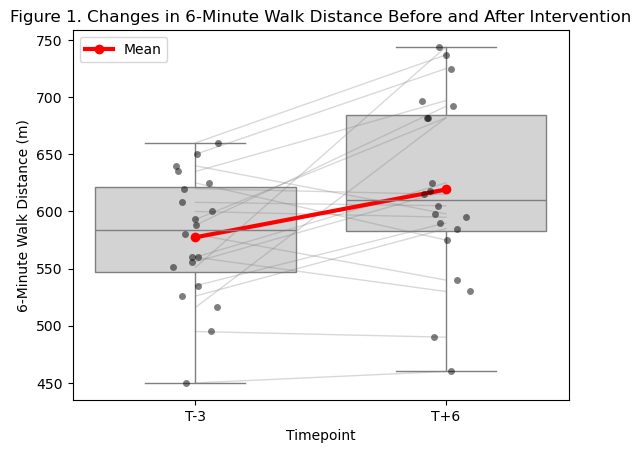

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Boxplot showing the distribution at each timepoint
sns.boxplot(
    data=distance_long,
    x="time",
    y="distance",
    color="lightgrey"
)

# Individual data points
sns.stripplot(
    data=distance_long,
    x="time",
    y="distance",
    color="black",
    alpha=0.5,
    jitter=True
)

# Paired lines for each patient (before → after)
for i in range(len(data_inclus)):
    plt.plot(
        ["T-3", "T+6"],
        [
            data_inclus["6minwt_distance_traveled_m_before"].iloc[i],
            data_inclus["6minwt_distance_traveled_m_after"].iloc[i]
        ],
        color="grey",
        alpha=0.3,
        linewidth=1
    )

# Compute mean values at each timepoint
mean_before = data_inclus["6minwt_distance_traveled_m_before"].mean()
mean_after = data_inclus["6minwt_distance_traveled_m_after"].mean()

# Add mean line (highlighted)
plt.plot(
    ["T-3", "T+6"],
    [mean_before, mean_after],
    color="red",
    linewidth=3,
    marker="o",
    label="Mean"
)

# Labels and title
plt.xlabel("Timepoint")
plt.ylabel("6-Minute Walk Distance (m)")
plt.title("Figure 1. Changes in 6-Minute Walk Distance Before and After Intervention")

# Legend
plt.legend()

# Save the figure
plt.savefig(
    "figures/Figure_1_Changes_in_6MWT_Before_After.pdf",
    bbox_inches="tight"
)

# Display the plot
plt.show()

### Interpretation : Figure 1.Changes in 6-Minute Walk Distance Before and After Intervention

Data were visualized using boxplots combined with individual data points and paired lines to illustrate changes in 6-minute walk distance between baseline (T−3) and post-intervention (T+6). This visualization was performed as an exploratory step prior to statistical analysis in R.

The boxplots show a shift toward higher values at T+6 compared to T−3, suggesting an overall improvement in functional capacity following the intervention. This trend is supported by the upward trajectory of most individual paired lines, indicating that the majority of patients experienced an increase in walking distance.

However, some variability is observed, with a few patients showing little or no improvement, or even a decrease in performance. The dispersion of the data highlights inter-individual differences in response to the intervention.

The mean values, represented by the red line, further emphasize the overall increase in 6-minute walk distance from baseline to post-intervention.

Overall, this figure provides an initial visual assessment of paired changes and supports the subsequent statistical analysis, indicating a general improvement in functional capacity after the intervention.

###  Figure 2. Distribution of Changes in 6-Minute Walk Distance

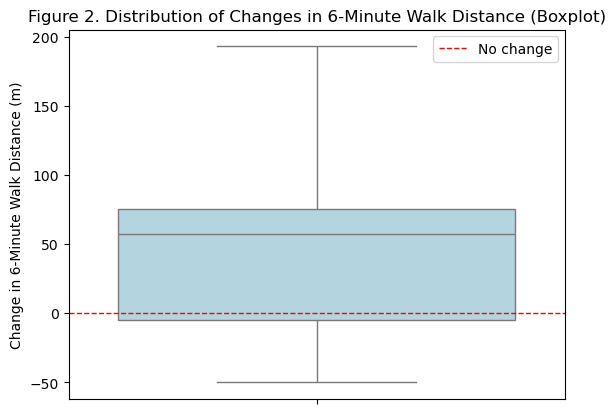

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

# Boxplot showing the distribution of individual changes (delta)
sns.boxplot(
    y=data_inclus["delta_6mwt"],
    color="lightblue"
)

# Add reference line at zero (no change)
plt.axhline(
    0,
    linestyle="--",
    color="red",
    linewidth=1,
    label="No change"
)

# Labels and title
plt.ylabel("Change in 6-Minute Walk Distance (m)")
plt.title("Figure 2. Distribution of Changes in 6-Minute Walk Distance (Boxplot)")

# Legend
plt.legend()

# Save the figure
plt.savefig(
    "figures/Figure_2_Boxplot_of_Changes_in_6-Minute_Walk_Distance.pdf",
    bbox_inches="tight"
)

# Display the plot
plt.show()

###  Interpretation : Figure 2. Distribution of Changes in 6-Minute Walk Distance

The distribution of individual changes in 6-minute walk distance (Δ6MWT) was visualized using a boxplot as a preliminary step before statistical analysis.

A horizontal reference line at zero was added to distinguish between improvement and decline in performance. The boxplot shows that the median change is above zero, suggesting an overall increase in 6-minute walk distance following the intervention.

Most values are distributed above the zero line, indicating that the majority of patients experienced an improvement in functional capacity. However, some negative values are observed, reflecting a subset of patients with no improvement or a decrease in performance.

This exploratory visualization supports the subsequent use of a non-parametric statistical test and provides an initial overview of the data distribution.

### Table 1. Distribution and changes in 6-minute walk distance

In [10]:
import pandas as pd 
import matplotlib.pyplot as plt

# ---- 1. FORMAT MEDIAN [IQR] ----
summary_table = distance_long.groupby("time")["distance"].agg(
    Median="median",
    Q1=lambda x: x.quantile(0.25),
    Q3=lambda x: x.quantile(0.75)
)

# Create formatted column
summary_table["Median [IQR]"] = (
    summary_table["Median"].round(1).astype(str) + " [" +
    summary_table["Q1"].round(1).astype(str) + "–" +
    summary_table["Q3"].round(1).astype(str) + "]"
)

# Keep only useful column
summary_table = summary_table[["Median [IQR]"]]

# Rename index
summary_table.index = ["T-3", "T+6"]


# ---- 2. DELTA SUMMARY ----
improvement = (data_inclus["delta_6mwt"] > 0).sum()
no_change = (data_inclus["delta_6mwt"] == 0).sum()
decrease = (data_inclus["delta_6mwt"] < 0).sum()

total = len(data_inclus)

delta_table = pd.DataFrame({
    "Change (n, %)": [
        f"{improvement} ({round(improvement/total*100,1)}%)",
        f"{no_change} ({round(no_change/total*100,1)}%)",
        f"{decrease} ({round(decrease/total*100,1)}%)"
    ]
}, index=["Improved", "No change", "Decreased"])


# ---- 3. FINAL TABLE (STACKED CLEAN) ----
final_table = pd.concat([summary_table, delta_table])


# ---- 4. EXPORT PDF ----
fig, ax = plt.subplots(figsize=(6,4))
ax.axis('off')

table = ax.table(
    cellText=final_table.values,
    colLabels=final_table.columns,
    rowLabels=final_table.index,
    loc='center'
)

# Title
plt.title(
    "Table 1. Distribution and changes in 6-minute walk distance",
    fontsize=12,
    pad=20
)

plt.savefig("figures/Table_1_Distribution_and_changes_in_6-minute_walk_distance.pdf", bbox_inches="tight")
plt.close()

from IPython.display import display

display(final_table.style.set_caption(
    "Table 1. Distribution and changes in 6-minute walk distance"
))

,Median [IQR],"Change (n, %)"
T-3,610.0 [582.5–684.5],nan
T+6,584.0 [547.0–621.2],nan
Improved,nan,12 (60.0%)
No change,nan,0 (0.0%)
Decreased,nan,8 (40.0%)


### Interpretation : Table 1. Distribution and changes in 6-minute walk distance

Descriptive statistics are presented as median [interquartile range] for each timepoint.

Individual changes in 6-minute walk distance are summarized as the number and percentage of patients who improved, remained stable, or decreased following the intervention. Notably, 12 out of 20 patients (60.0%) showed an improvement, while 8 patients (40.0%) exhibited a decrease and none remained stable.

This table provides a concise overview of both the distribution of values at baseline and post-intervention, as well as the direction of individual changes, allowing for an initial interpretation prior to statistical testing.

## Step 7 : Export data to R

In [11]:
# Export data for further analysis
data_inclus.to_excel("data/data_clean.xlsx", index=False)
data_exclus.to_excel("data/data_excluded.xlsx", index=False)

## Conclusion

Cleaned datasets were exported for statistical analysis in R.

The primary analysis was conducted on patients with complete data, while excluded patients were analyzed separately to assess potential selection bias.

The 6-minute walk test (6MWT) was defined as the primary outcome of the study.

An initial exploratory analysis was performed in Python to visualize and describe the data prior to statistical testing. A boxplot combined with individual paired trajectories (Figure 1) was used to illustrate changes in 6MWT distance between baseline and post-intervention, suggesting an overall improvement in functional capacity.

The distribution of individual changes was further explored using a boxplot of Δ6MWT (Figure 2), allowing identification of the direction and variability of changes, and providing a visual distinction between improvement and decline.

Descriptive statistics (Table 1) were calculated and presented as median [IQR], along with the number and percentage of patients who improved, remained stable, or decreased, offering a concise summary of both central tendency and individual responses prior to statistical analysis.

Statistical analyses were then performed using R, including paired comparisons of pre- and post-intervention values using appropriate tests.

To ensure clarity of the analyses, no formal statistical analysis was performed on VAT.

However, an exploratory correlation analysis between 6MWT and PedsQL scores was conducted to assess the relationship between functional capacity and quality of life.